In [1]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

import pickle
import os

from pathlib import Path

Methods = ['rates','uniform','gaussian', 'lognormal', 'powerlaw']
P_low_z = np.zeros(len(Methods), dtype=float)
P_high_z = np.zeros(len(Methods), dtype=float)

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# 1. 先定义完整的范围
N_total = 1000
all_z_range = np.linspace(0, 2.0, N_total)

# 2. 找到最接近 0.2 的索引位置
split_idx = np.argmin(np.abs(all_z_range - 0.2))

# 3. 这里的切片确保了点不重叠
# low 包含从 0 到 0.2 之前的点
# high 包含从 0.2 到 2.0 的点
low_z_part = all_z_range[:split_idx]
high_z_part = all_z_range[split_idx:]

for i, Method in enumerate(Methods):
    # 计算全范围的分布函数值
    f_all = redshift_distribution(all_z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, w=W_LAMBDA, method=Method)
    
    # 直接对数组切片求和
    sum_all = np.sum(f_all)
    sum_low = np.sum(f_all[:split_idx])
    sum_high = np.sum(f_all[split_idx:])
    
    P_low_z[i] = sum_low / sum_all
    P_high_z[i] = sum_high / sum_all
    
    print(f"Method: {Method}, Total: {P_low_z[i] + P_high_z[i]:.2f}") # 此时结果必然为 1.0

Method: rates, Total: 1.00
Method: uniform, Total: 1.00
Method: gaussian, Total: 1.00
Method: lognormal, Total: 1.00
Method: powerlaw, Total: 1.00


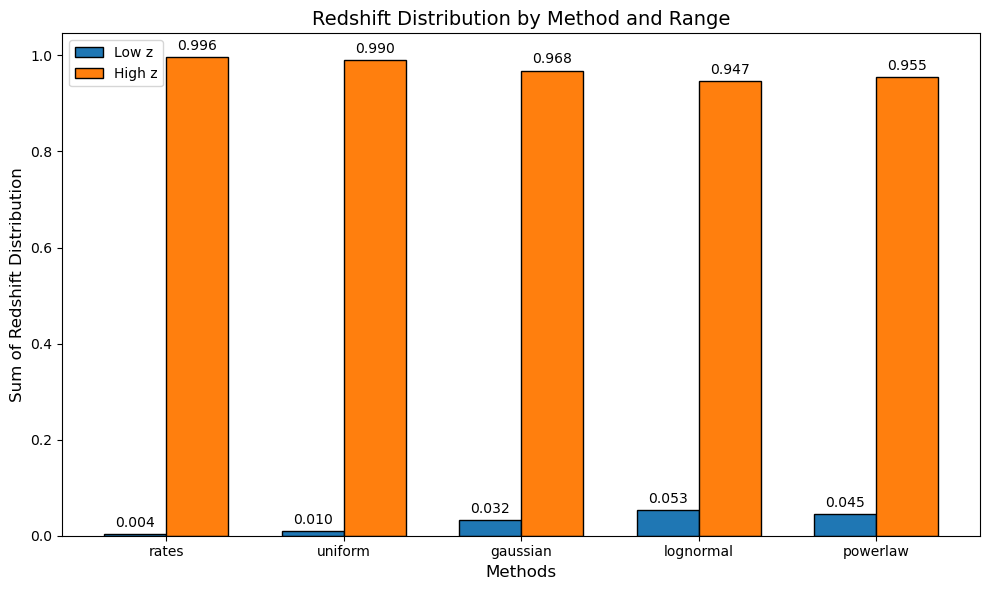

In [3]:
# 设置柱状图的宽度
bar_width = 0.35

# 设置每组柱子的位置
index = np.arange(len(Methods))

# 创建绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 画 Low z 的柱子
bar1 = ax.bar(index - bar_width/2, P_low_z, bar_width, 
                label='Low z', color='#1f77b4', edgecolor='black')

# 画 High z 的柱子
bar2 = ax.bar(index + bar_width/2, P_high_z, bar_width, 
                label='High z', color='#ff7f0e', edgecolor='black')

# 添加标签、标题和图例
ax.set_xlabel('Methods', fontsize=12)
ax.set_ylabel('Sum of Redshift Distribution', fontsize=12)
ax.set_title('Redshift Distribution by Method and Range', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(Methods)
ax.legend()

# 可选：在柱子顶部显示数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bar1)
autolabel(bar2)

plt.tight_layout()
plt.show()